In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier

from sklearn.model_selection import cross_val_score, cross_val_predict
import numpy as np
from sklearn.metrics import make_scorer, f1_score

# Carga del dataset

In [2]:
train_df = pd.read_csv(r'dataset/train.csv', index_col='CustomerId')
train_df

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CustomerId,,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,0
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,0
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,0
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73,0
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05,0
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38,1


In [3]:
X = train_df.drop(columns=['Exited'])
y = train_df['Exited']

In [4]:
X

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86
...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38


In [5]:
y

CustomerId
15759244    0
15725997    0
15724296    0
15636820    0
15744529    0
           ..
15628303    0
15699225    0
15612525    1
15724321    1
15578761    1
Name: Exited, Length: 8000, dtype: int64

In [6]:
test_df = pd.read_csv(r'dataset/test.csv', index_col='CustomerId')
test_df

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
CustomerId,,,,,,,,,,,
15764618,Tseng,815.0,Spain,Female,39,6,0.00,1.0,1.0,1,85167.88
15626385,George,714.0,Spain,Female,33,10,103121.33,2.0,1.0,1,49672.01
15687413,Sunderland,619.0,Spain,Female,38,6,0.00,2.0,1.0,1,117616.29
15759067,Bromby,537.0,Germany,Female,37,7,158411.95,4.0,1.0,1,117690.58
15614049,Hu,664.0,France,Male,55,8,0.00,2.0,1.0,1,139161.64
...,...,...,...,...,...,...,...,...,...,...,...
15572956,Steen,683.0,France,Male,36,5,115350.63,NaN,NaN,1,122305.91
15714080,Goliwe,NaN,Germany,Female,40,2,NaN,2.0,1.0,0,NaN
15637366,Su,505.0,Germany,Female,25,5,114268.85,2.0,1.0,1,126728.27


# Análisis exploratorio

**Características principales**
1. Identificación del cliente
    - ```CustomerId```: ID único del cliente
    - ```Surname```: Apellido del cliente
2. Información financiera
    - ```CreditScore```: Calificación crediticia. Establece la capacidad de una persona para pagar su deuda y el riesgo que conlleva invertir con ella.
    - ```Balance```: Saldo en la cuenta bancaria
    - ```NumOfProducts```: Número de productos bancarios que utiliza
    - ```HasCrCard```: Si tiene tarjeta de crédito (0 = no, 1 = sí)
    - ```EstimatedSalary```: Salario estimado
3. Información demográfica y personal
    - ```Geography```: País de residencia
    - ```Gender```: Género (Male/Female)
    - ```Age```: Edad
    - ```Tenure```: Años como cliente del banco
    - ```IsActiveMember```: Si es un miembro activo del banco (0 = no, 1 = sí)
4. Variable objetivo
    - ```Exited```: Indicador binario de abandono del banco (0 = se queda, 1 = se va)

**Tipo de datos**
- Numéricos: ```Integer``` o ```Float``` (```CreditScore```, ```Age```, ```Balance```, ```EstimatedSalary```, etc.)
- Categóricos: ```Gender```, ```Geography```, ```HasCrCard```, ```IsActiveMember```, ```Exited```

In [7]:
cat_cols = ['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']
num_cols = [col for col in X.columns if col not in cat_cols and col != 'Surname']

print(cat_cols)
print(num_cols)

['Gender', 'Geography', 'HasCrCard', 'IsActiveMember']
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']


In [8]:
print("\nDimensiones del dataset:")
print(X.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts().sort_index())

print("\nEstadísticas descriptivas:")
print(X.describe())


Dimensiones del dataset:
(8000, 11)

Distribución de la variable objetivo:
Exited
0    6370
1    1630
Name: count, dtype: int64

Estadísticas descriptivas:
       CreditScore          Age       Tenure        Balance  NumOfProducts  \
count  6359.000000  8000.000000  8000.000000    6385.000000    7024.000000   
mean    661.235257    38.935000     5.013875   76929.669179       1.539721   
std      95.876126    10.381389     2.888810   62292.133487       0.574125   
min     350.000000    18.000000     0.000000       0.000000       1.000000   
25%     595.000000    32.000000     3.000000       0.000000       1.000000   
50%     664.000000    37.000000     5.000000   98009.130000       2.000000   
75%     729.000000    44.000000     8.000000  127660.460000       2.000000   
max     850.000000    92.000000    10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary  
count  7625.000000     8000.000000      7168.000000  
mean      0.706623        0.5135

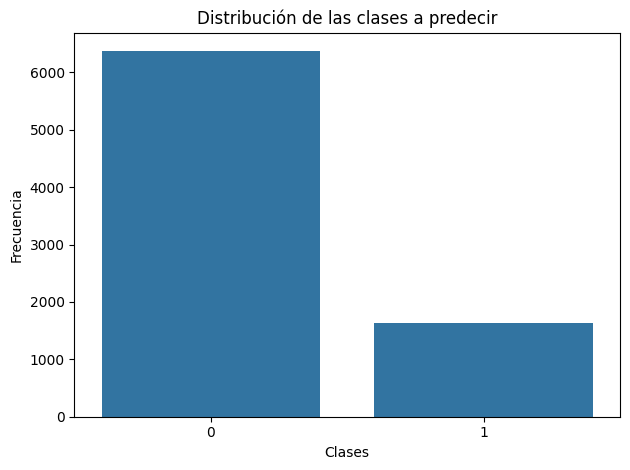

In [9]:
sns.countplot(data=train_df, x="Exited")
plt.title("Distribución de las clases a predecir")
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## Detección de valores anómalos/extremos

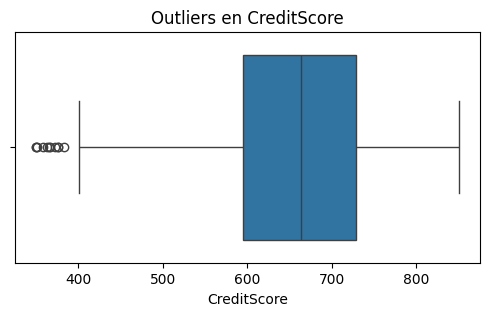

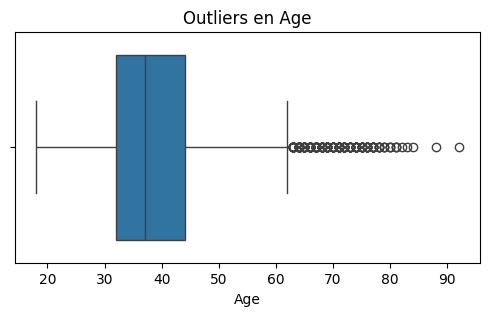

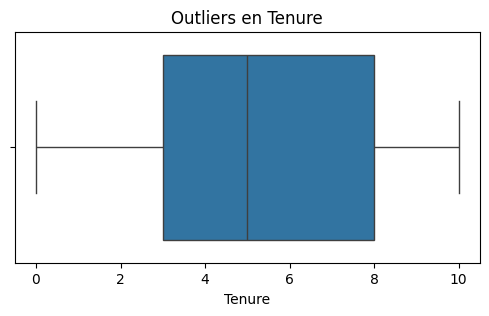

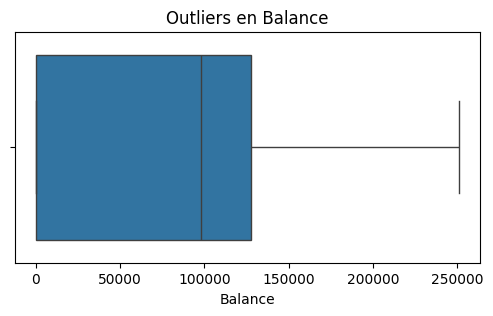

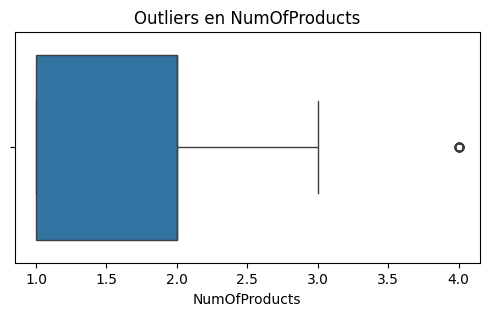

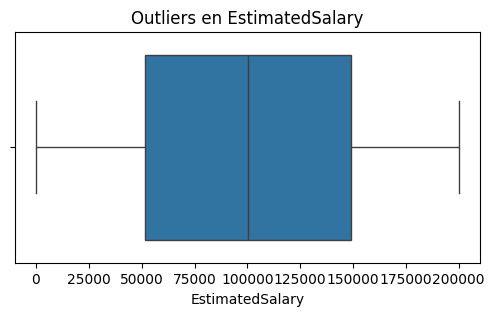

In [10]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=X[col])
    plt.title(f"Outliers en {col}")
    plt.show()

## Valores faltantes

In [11]:
print("\nValores faltantes por columna:")
print(X.isnull().sum())


Valores faltantes por columna:
Surname             409
CreditScore        1641
Geography             0
Gender                0
Age                   0
Tenure                0
Balance            1615
NumOfProducts       976
HasCrCard           375
IsActiveMember        0
EstimatedSalary     832
dtype: int64


## Correlacion

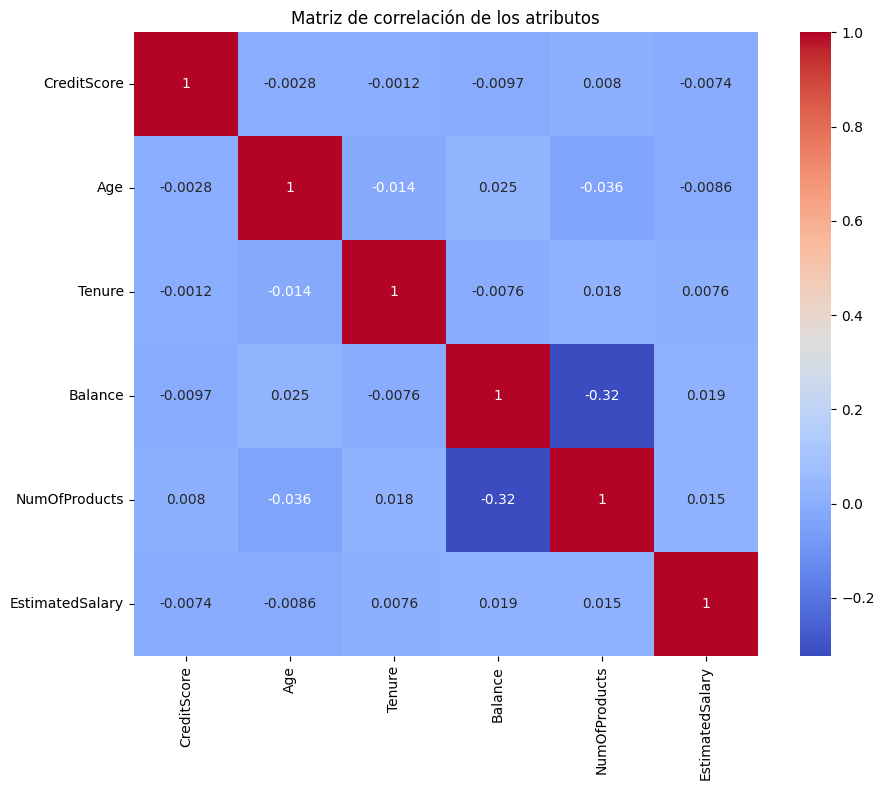

                 CreditScore       Age    Tenure   Balance  NumOfProducts  \
CreditScore         1.000000 -0.002823 -0.001184 -0.009667       0.007970   
Age                -0.002823  1.000000 -0.013730  0.025038      -0.035964   
Tenure             -0.001184 -0.013730  1.000000 -0.007552       0.018016   
Balance            -0.009667  0.025038 -0.007552  1.000000      -0.323886   
NumOfProducts       0.007970 -0.035964  0.018016 -0.323886       1.000000   
EstimatedSalary    -0.007368 -0.008610  0.007587  0.019494       0.014698   

                 EstimatedSalary  
CreditScore            -0.007368  
Age                    -0.008610  
Tenure                  0.007587  
Balance                 0.019494  
NumOfProducts           0.014698  
EstimatedSalary         1.000000  


In [12]:
# Correlación entre atributos
plt.figure(figsize=(10, 8))
sns.heatmap(
    X[num_cols].corr(),
    cmap="coolwarm",
    annot=True,
    square=True
)
plt.title("Matriz de correlación de los atributos")
plt.tight_layout()
plt.show()

print(X[num_cols].corr())

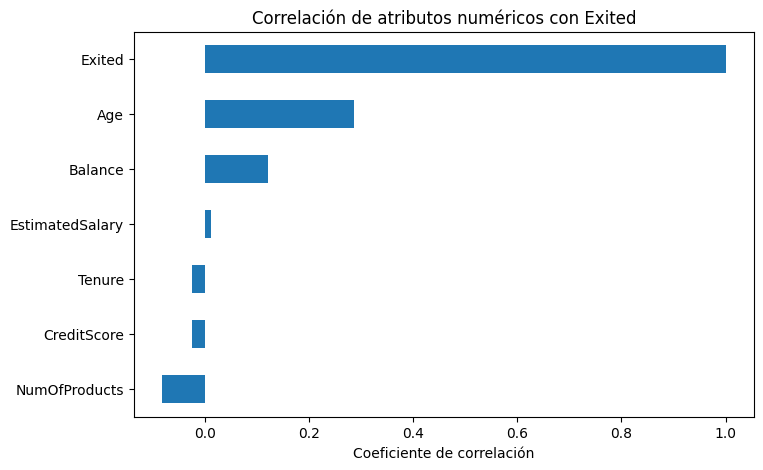

In [13]:
# Correlacion con la variable a predecir
corr_series = X[num_cols].join(y).corr()['Exited'].sort_values()

plt.figure(figsize=(8,5))
corr_series.plot(kind='barh')
plt.title('Correlación de atributos numéricos con Exited')
plt.xlabel('Coeficiente de correlación')
plt.show()

## Analisis de variables categoricas


Distribución de Gender:
Gender
Male      4384
Female    3616
Name: count, dtype: int64


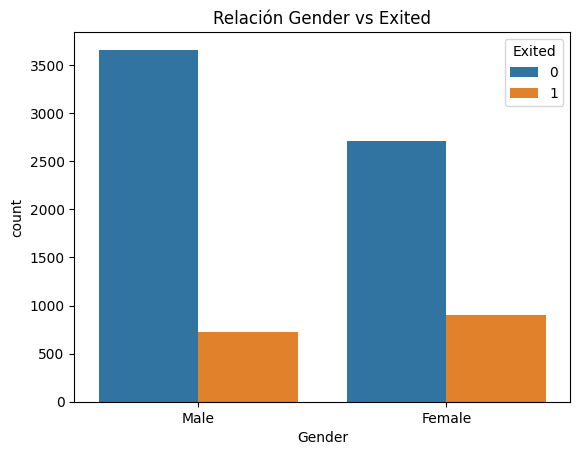


Distribución de Geography:
Geography
France     4030
Germany    1986
Spain      1984
Name: count, dtype: int64


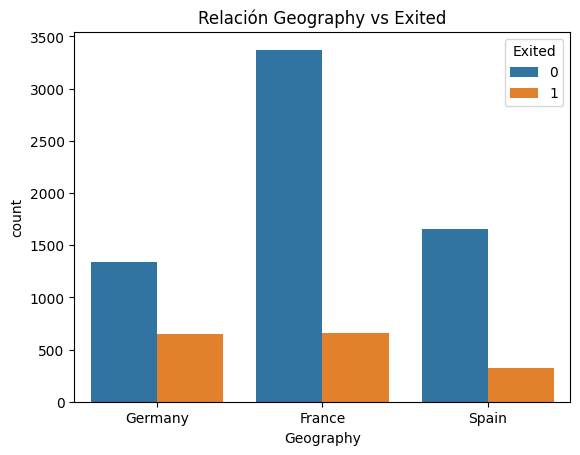


Distribución de HasCrCard:
HasCrCard
1.0    5388
0.0    2237
Name: count, dtype: int64


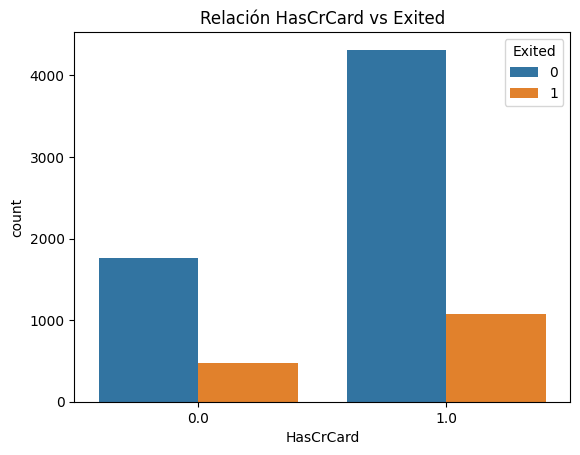


Distribución de IsActiveMember:
IsActiveMember
1    4108
0    3892
Name: count, dtype: int64


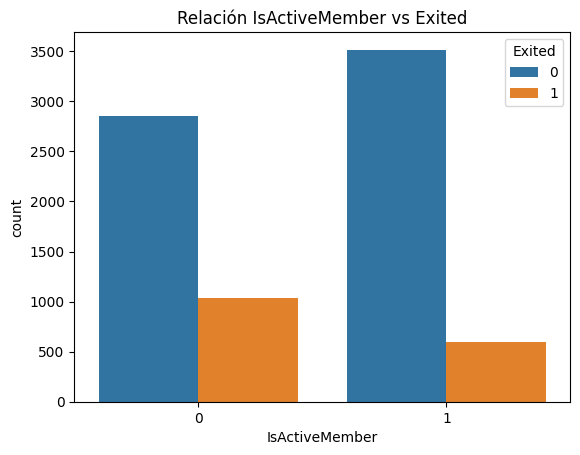

In [14]:
for col in cat_cols:
    print(f"\nDistribución de {col}:")
    print(train_df[col].value_counts())
    
    sns.countplot(data=train_df, x=col, hue='Exited')
    plt.title(f"Relación {col} vs Exited")
    plt.show()


## Creación de nuevos atributos

In [15]:
# Capacidad financiera
X['BalanceSalaryRatio'] = X['Balance'] / (X['EstimatedSalary'] + 1)

# Balance por edad
X['BalancePerAge'] = X['Balance'] / (X['Age'] + 1)

# Score crediticio del cliente relativo al balance
X['CreditScorePerBalance'] = X['CreditScore'] / (X['Balance'] + 1)

X

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,BalancePerAge,CreditScorePerBalance
CustomerId,,,,,,,,,,,,,,
15759244,Boone,687.0,Germany,Male,44,8,95368.14,2.0,1.0,1,1787.85,53.312542,2119.292000,0.007204
15725997,She,660.0,France,Female,35,6,100768.77,1.0,1.0,0,19199.61,5.248207,2799.132500,0.006550
15724296,Kerr,684.0,Spain,Male,41,2,119782.72,2.0,0.0,0,120284.67,0.995819,2851.969524,0.005710
15636820,Loggia,725.0,Germany,Male,40,8,104149.66,1.0,1.0,0,62027.90,1.679051,2540.235610,0.006961
15744529,Chiekwugo,510.0,France,Male,63,8,0.00,2.0,1.0,1,115291.86,0.000000,0.000000,510.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15628303,Thurgood,738.0,Spain,Male,35,3,0.00,1.0,1.0,1,15650.73,0.000000,0.000000,738.000000
15699225,Pirozzi,757.0,France,Male,46,0,0.00,2.0,1.0,0,37460.05,0.000000,0.000000,757.000000
15612525,Preston,NaN,France,Female,57,1,NaN,1.0,0.0,0,131372.38,NaN,NaN,NaN


# Preprocesamiento

In [16]:
# Transformaciones de variables numericas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformaciones de variables categoricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Modelos

In [68]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM (RBF)": SVC(kernel='rbf', probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LightGBM": LGBMClassifier()
}

In [69]:
# from catboost import CatBoostClassifier

# models["CatBoost"] = CatBoostClassifier(
#     verbose=False,
#     depth=8,
#     iterations=500,
#     learning_rate=0.05
# )


from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class CatBoostSklearn(BaseEstimator, ClassifierMixin):
    def __init__(self, **kwargs):
        self.model = CatBoostClassifier(**kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def predict(self, X):
        preds = self.model.predict(X)
        return preds.astype(int)

    def predict_proba(self, X):
        return self.model.predict_proba(X)

    def get_params(self, deep=True):
        return self.model.get_params()

    def set_params(self, **params):
        self.model.set_params(**params)
        return self

models["CatBoost"] = CatBoostSklearn(depth=8, iterations=500, learning_rate=0.05)



In [ ]:
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Función de construcción compatible con scikeras
def build_nn(X=None, y=None):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X.shape[1],)),  # input_shape explícito
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  # salida binaria
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Wrapper scikeras
nn_model = KerasClassifier(model=build_nn, epochs=20, batch_size=32, verbose=0)


# Entrenamiento

In [ ]:
f1_scorer = make_scorer(f1_score, greater_is_better=True)

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf', model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring=f1_scorer, n_jobs=-1)
        
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: F1 = 0.3123 ± 0.0184
Logistic Regression: F1 = (np.float64(0.31228856324856674), np.float64(0.018375443804477972))
Decision Tree: F1 = 0.4751 ± 0.0146
Decision Tree: F1 = (np.float64(0.4750993581682648), np.float64(0.014640467458935274))
Random Forest: F1 = 0.5434 ± 0.0143
Random Forest: F1 = (np.float64(0.5433632907391028), np.float64(0.01431955319516669))
Gradient Boosting: F1 = 0.5593 ± 0.0198
Gradient Boosting: F1 = (np.float64(0.5593131830403798), np.float64(0.019807314714557794))
XGBoost: F1 = 0.5509 ± 0.0220
XGBoost: F1 = (np.float64(0.550900250126221), np.float64(0.022033180145069168))


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:19:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:19:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:19:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [17:19:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/hom

SVM (RBF): F1 = 0.4952 ± 0.0198
SVM (RBF): F1 = (np.float64(0.4951885986294289), np.float64(0.019832659326575283))
KNN: F1 = 0.4876 ± 0.0143
KNN: F1 = (np.float64(0.48757811432609965), np.float64(0.014276748242619831))
Naive Bayes: F1 = 0.4358 ± 0.0120
Naive Bayes: F1 = (np.float64(0.4357502756845418), np.float64(0.011971443626855392))
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Number of positive: 1304, number of negative: 5096
[LightGBM] [Info] Auto-choosing co

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature nam

LightGBM: F1 = 0.5683 ± 0.0183
LightGBM: F1 = (np.float64(0.5682743756039523), np.float64(0.018343446095007064))
0:	learn: 0.6571557	total: 50.1ms	remaining: 25s
0:	learn: 0.6592807	total: 51.1ms	remaining: 25.5s
0:	learn: 0.6573386	total: 51.5ms	remaining: 25.7s
1:	learn: 0.6267194	total: 55.6ms	remaining: 13.8s
1:	learn: 0.6232470	total: 56.9ms	remaining: 14.2s
2:	learn: 0.5933949	total: 59.3ms	remaining: 9.82s
2:	learn: 0.5922886	total: 63.3ms	remaining: 10.5s
1:	learn: 0.6254286	total: 62.1ms	remaining: 15.5s
0:	learn: 0.6578556	total: 52.5ms	remaining: 26.2s
3:	learn: 0.5655165	total: 68.1ms	remaining: 8.45s
3:	learn: 0.5649307	total: 69.5ms	remaining: 8.61s
4:	learn: 0.5407305	total: 74.2ms	remaining: 7.35s
4:	learn: 0.5403529	total: 73.7ms	remaining: 7.3s
0:	learn: 0.6557972	total: 57.3ms	remaining: 28.6s
5:	learn: 0.5233243	total: 75.8ms	remaining: 6.24s
1:	learn: 0.6251801	total: 65.6ms	remaining: 16.3s
2:	learn: 0.5942864	total: 77.9ms	remaining: 12.9s
6:	learn: 0.5049009	tot

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), N

353:	learn: 0.1985221	total: 3.15s	remaining: 1.3s
224:	learn: 0.2427654	total: 3.17s	remaining: 3.88s
354:	learn: 0.1982947	total: 3.16s	remaining: 1.29s
242:	learn: 0.2302473	total: 3.18s	remaining: 3.36s
418:	learn: 0.1802309	total: 3.14s	remaining: 607ms
355:	learn: 0.1980771	total: 3.16s	remaining: 1.28s
356:	learn: 0.1979032	total: 3.16s	remaining: 1.27s
225:	learn: 0.2424134	total: 3.18s	remaining: 3.86s
357:	learn: 0.1978190	total: 3.17s	remaining: 1.26s
358:	learn: 0.1976834	total: 3.17s	remaining: 1.25s
243:	learn: 0.2298906	total: 3.19s	remaining: 3.35s
419:	learn: 0.1800628	total: 3.15s	remaining: 600ms
359:	learn: 0.1974541	total: 3.17s	remaining: 1.23s
420:	learn: 0.1798970	total: 3.15s	remaining: 592ms
360:	learn: 0.1972766	total: 3.18s	remaining: 1.22s
361:	learn: 0.1971553	total: 3.18s	remaining: 1.21s
244:	learn: 0.2296165	total: 3.2s	remaining: 3.33s
362:	learn: 0.1968317	total: 3.18s	remaining: 1.2s
226:	learn: 0.2421925	total: 3.2s	remaining: 3.85s
421:	learn: 0.17

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), N

296:	learn: 0.2191620	total: 3.78s	remaining: 2.59s
481:	learn: 0.1660678	total: 3.75s	remaining: 140ms
297:	learn: 0.2188744	total: 3.79s	remaining: 2.57s
482:	learn: 0.1658290	total: 3.75s	remaining: 132ms
298:	learn: 0.2186771	total: 3.79s	remaining: 2.55s
297:	learn: 0.2139196	total: 3.8s	remaining: 2.58s
483:	learn: 0.1657158	total: 3.75s	remaining: 124ms
299:	learn: 0.2184139	total: 3.79s	remaining: 2.53s
484:	learn: 0.1655821	total: 3.76s	remaining: 116ms
300:	learn: 0.2182477	total: 3.8s	remaining: 2.51s
301:	learn: 0.2179182	total: 3.8s	remaining: 2.49s
298:	learn: 0.2137180	total: 3.81s	remaining: 2.56s
302:	learn: 0.2176271	total: 3.8s	remaining: 2.47s
485:	learn: 0.1653675	total: 3.77s	remaining: 109ms
303:	learn: 0.2170860	total: 3.81s	remaining: 2.46s
304:	learn: 0.2167292	total: 3.81s	remaining: 2.44s
299:	learn: 0.2135117	total: 3.82s	remaining: 2.55s
486:	learn: 0.1650478	total: 3.77s	remaining: 101ms
305:	learn: 0.2165425	total: 3.81s	remaining: 2.42s
487:	learn: 0.16

/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 96, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/_response.py", line 242, in _get_response_values
    y_pred, pos_label = prediction_method(X), N

In [48]:
nn_pipeline = Pipeline([
    ("preprocess", preprocessor),  # tu ColumnTransformer
    ("clf", nn_model)
])

scores = cross_val_score(nn_pipeline, X, y, cv=5, scoring='f1')
print("F1 medio:", scores.mean())

NameError: name 'nn_model' is not defined

# Visualización de resultados

In [49]:
df_results = pd.DataFrame(results, index=["F1"]).T
df_results = df_results.sort_values("F1", ascending=False)
df_results

,F1
LightGBM,0.568591
Gradient Boosting,0.559533
XGBoost,0.551347
Random Forest,0.548375
SVM (RBF),0.495553
KNN,0.487731
Decision Tree,0.480884
Naive Bayes,0.435667
Logistic Regression,0.312217


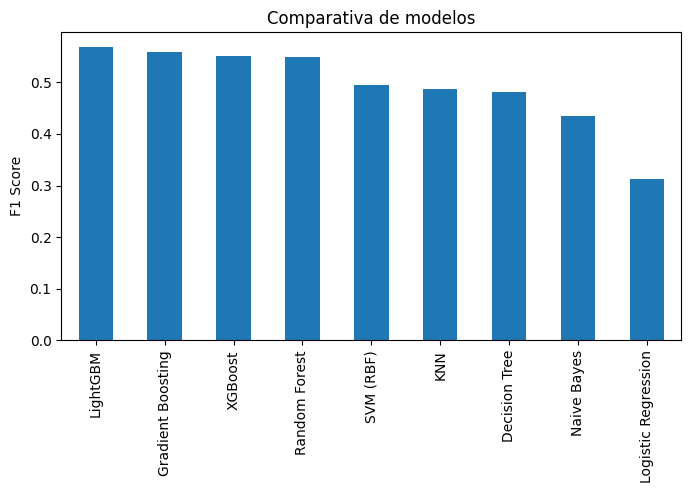

In [51]:
df_results['F1'].plot(kind='bar', figsize=(8,4))
plt.ylabel('F1 Score')
plt.title('Comparativa de modelos')
plt.show()


# Predecir

In [53]:
# Ejemplo: seleccionar el modelo con mayor F1
best_model_name = max(results, key=lambda k: results[k])
print("Mejor modelo según F1:", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('clf', best_model)
])

best_pipeline.fit(X, y)

y_test_pred = best_pipeline.predict(test_df)

submission = pd.DataFrame({
    "CustomerId": test_df.index,  # si CustomerId está como índice
    "Exited": y_test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

Mejor modelo según F1: LightGBM
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019


/home/mayumar/Escritorio/CyD/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,CustomerId,Exited
0,15764618,0
1,15626385,0
2,15687413,0
3,15759067,1
4,15614049,0
